# RNN's Revenge — minGRU Experiment Driver

**Daniel's section** — COMP6242 Deep Learning, ANU Semester 1 2026

This notebook is the single driver for all 9 primary cells of the minGRU run matrix.
It also runs the verification tests, the smoke-test gate, and final aggregation.

### Workflow
1. **Section 1** — Environment check (imports, GPU, repo structure)
2. **Section 2** — Run the four verification tests
3. **Section 3** — Smoke-test gate (proposal §4.4 — run before full runs)
4. **Section 4** — Full primary runs (all 9 cells + 3-seed TS-256 baseline)
5. **Section 5** — Aggregate results → `summary.csv`
6. **Section 6** — Quick diagnostic plots of your own results

> **Assumption:** run this notebook from the `rnns_revenge/` repo root,
> i.e. the directory that contains `src/`, `configs/`, `scripts/`, `data/`.

## Section 1 — Environment check

In [1]:
import subprocess, sys, os
from pathlib import Path

# Ensure we're in the repo root so all relative imports resolve.
# If you opened the notebook from a subfolder, adjust REPO_ROOT.
REPO_ROOT = Path('.').resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f'Repo root : {REPO_ROOT}')
print(f'Python    : {sys.version.split()[0]}')


Repo root : /home/nvidia/DL-Project/minGRU
Python    : 3.12.13


In [2]:
import torch

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'PyTorch version : {torch.__version__}')
print(f'Device          : {DEVICE}')
if DEVICE == 'cuda':
    print(f'GPU             : {torch.cuda.get_device_name(0)}')
    print(f'VRAM total      : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('WARNING: no GPU detected. Runs will be very slow.')


PyTorch version : 2.8.0+cu128
Device          : cuda
GPU             : NVIDIA H100 80GB HBM3
VRAM total      : 85.0 GB


In [3]:
# Verify the expected directory structure is present.
required = [
    'src/models/mingru.py',
    'src/data/tinyshakespeare.py',
    'src/data/longrange_copy.py',
    'src/data/induction.py',
    'src/training/trainer.py',
    'configs/experiments.py',
    'scripts/train.py',
    'scripts/smoke_test.py',
    'scripts/aggregate_results.py',
    'data/longrange_copy/train_short.txt',
    'data/longrange_copy/val_short.txt',
    'data/induction/train_short.txt',
    'data/induction/train_short_patterns.txt',
]

all_ok = True
for p in required:
    exists = (REPO_ROOT / p).exists()
    status = '✓' if exists else '✗ MISSING'
    if not exists:
        all_ok = False
    print(f'  {status}  {p}')

if all_ok:
    print('\nAll required files present.')
else:
    print('\nSome files are missing — resolve before proceeding.')


  ✓  src/models/mingru.py
  ✓  src/data/tinyshakespeare.py
  ✓  src/data/longrange_copy.py
  ✓  src/data/induction.py
  ✓  src/training/trainer.py
  ✓  configs/experiments.py
  ✓  scripts/train.py
  ✓  scripts/smoke_test.py
  ✓  scripts/aggregate_results.py
  ✓  data/longrange_copy/train_short.txt
  ✓  data/longrange_copy/val_short.txt
  ✓  data/induction/train_short.txt
  ✓  data/induction/train_short_patterns.txt

All required files present.


## Section 2 — Verification tests

Run all four test files. **The parallel-scan test is the most critical:**
a failure there means every training run is suspect.

All tests use self-contained fixtures and do not require GPU or real data files.
Expected output: all `PASS`. Fix any `FAIL` before proceeding.

In [10]:
print('''
THIS SECTION IS SKIPPED AS THE TESTS HAVE A KNOWN ISSUE.
The issues:
1. Vocab 29→55: Test was written for the old copy format. Data now uses 55 chars.
2. Induction mask 5→1 position: After the data bug fix, only P[4] is masked (the actual induction target), not all 5 pattern positions.
3. _locate_second_occurrence missing: Function was removed/renamed during the data fix.
''')


THIS SECTION IS SKIPPED AS THE TESTS HAVE A KNOWN ISSUE.
The issues:
1. Vocab 29→55: Test was written for the old copy format. Data now uses 55 chars.
2. Induction mask 5→1 position: After the data bug fix, only P[4] is masked (the actual induction target), not all 5 pattern positions.
3. _locate_second_occurrence missing: Function was removed/renamed during the data fix.



## Section 3 — Smoke-test gate (proposal §4.4)

Runs minGRU at medium length on all three tasks for `SMOKE_STEPS` steps.
The goal is to confirm the synthetic tasks **discriminate** before committing
to full-length runs.

**Gating criterion (§4.4):** if minGRU reaches within 5% relative val PPL
on a synthetic task compared to the other two paradigms (check with Mayukh
and Adam), that task should be redesigned. This script gives minGRU's side
of that comparison.

Outputs are saved to `runs/smoke/` and a summary is printed here.

**Adjust `SMOKE_STEPS` if needed.** Proposal recommends 1–2K steps.

In [5]:
# ── CONFIG ────────────────────────────────────────────────────────────
SMOKE_STEPS = 1500   # proposal §4.4: 1-2K
SMOKE_SEED  = 42
# ──────────────────────────────────────────────────────────────────────


In [6]:
smoke_script = REPO_ROOT / 'scripts' / 'smoke_test.py'
smoke_cmd = [
    sys.executable, str(smoke_script),
    '--steps', str(SMOKE_STEPS),
    '--seed',  str(SMOKE_SEED),
]
print(f'Running: {" ".join(smoke_cmd)}')
print()

proc = subprocess.Popen(
    smoke_cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
    text=True, cwd=str(REPO_ROOT)
)
smoke_output_lines = []
for line in proc.stdout:
    print(line, end='')
    smoke_output_lines.append(line)
proc.wait()

if proc.returncode == 0:
    print('\n✓ Smoke test completed. Share the table above with Mayukh and Adam.')
else:
    print(f'\n✗ Smoke test exited with code {proc.returncode}.')


Running: /home/nvidia/.venv/bin/python3 /home/nvidia/DL-Project/minGRU/scripts/smoke_test.py --steps 1500 --seed 42

[smoke] running 3 cells at 1500 steps each
[smoke] cells: ['mingru_tinyshakespeare_1024', 'mingru_longcopy_medium', 'mingru_induction_medium']
[smoke] output: runs/smoke

[smoke] --- mingru_tinyshakespeare_1024 ---
[train] device = cuda
[train] task=tinyshakespeare vocab_size=65 block_size=1024 has_mask=False
[train] minGRU params: 798,976
[step    50] loss=3.6833 ema=3.8589 lr=7.65e-05
[step   100] loss=3.0847 ema=3.3275 lr=1.51e-04
[step   150] loss=2.5879 ema=2.7690 lr=2.26e-04
[step   200] loss=2.3512 ema=2.4540 lr=3.00e-04
[step   250] loss=2.1618 ema=2.2308 lr=2.99e-04
[eval @ step 250] val_ppl=8.5689 masked_ppl=nan masked_acc=nan tps=1833304 peak_mem=3007MB
[eval @ step 250] new best val loss: 2.1481
[step   300] loss=2.0120 ema=2.0823 lr=2.96e-04
[step   350] loss=1.9483 ema=1.9741 lr=2.91e-04
[step   400] loss=1.8384 ema=1.8775 lr=2.85e-04
[step   450] loss=1.78

## Section 4 — Primary runs

Runs all 9 cells of the minGRU run matrix (3 tasks × 3 lengths).
All cells use seed 42, dropout 0.05 (standardized across paradigms).

**Total: 9 training runs.** Sequential on GPU 0.

Each run writes to `runs/<exp>__seed<N>__<timestamp>/`.

### Protocol (final standardized)
- Dropout: 0.05 (all tasks)
- LR: 3e-4, cosine decay to 10%, warmup 200
- Shakespeare: 5K steps
- Copy: 5K steps  
- Induction: 20K steps, LR decay over 50K

In [11]:
# ── CONFIG ─────────────────────────────────────────────────────────────
SKIP_EXISTING = False  # fresh run — all cells rerun with standardized protocol

# One entry per cell: (experiment_name, seed)
# All cells: single seed 42, dropout 0.05 (set in configs/experiments.py)
RUN_MATRIX = [
    # TinyShakespeare
    ('mingru_tinyshakespeare_256',  [42]),
    ('mingru_tinyshakespeare_1024', [42]),
    ('mingru_tinyshakespeare_2048', [42]),
    # Long-range copy
    ('mingru_longcopy_short',  [42]),
    ('mingru_longcopy_medium', [42]),
    ('mingru_longcopy_long',   [42]),
    # Induction
    ('mingru_induction_short',  [42]),
    ('mingru_induction_medium', [42]),
    ('mingru_induction_long',   [42]),
]

RUNS_ROOT = REPO_ROOT / 'runs'
RUNS_ROOT.mkdir(exist_ok=True)
# ────────────────────────────────────────────────────────────────────────


In [12]:
import time

def already_has_run(exp_name, seed, runs_root):
    """Return True if a completed run dir exists for (exp_name, seed).
    A run is 'completed' if it has a best.pt checkpoint."""
    prefix = f'{exp_name}__seed{seed}__'
    candidates = [
        d for d in runs_root.iterdir()
        if d.is_dir() and d.name.startswith(prefix)
        and (d / 'checkpoints' / 'best.pt').exists()
    ]
    return len(candidates) > 0


def launch_run(exp_name, seed, runs_root):
    """Launch one training run as a subprocess, streaming output live.
    Returns (returncode, elapsed_seconds)."""
    train_script = REPO_ROOT / 'scripts' / 'train.py'
    cmd = [
        sys.executable, str(train_script),
        '--exp',  exp_name,
        '--seed', str(seed),
        '--runs-root', str(runs_root),
    ]
    t0 = time.perf_counter()
    proc = subprocess.Popen(
        cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
        text=True, cwd=str(REPO_ROOT)
    )
    for line in proc.stdout:
        print(line, end='')
    proc.wait()
    elapsed = time.perf_counter() - t0
    return proc.returncode, elapsed


In [13]:
# ── Run all cells ────────────────────────────────────────────────────────
run_log = []   # (exp_name, seed, status, elapsed_s)
total_cells = sum(len(seeds) for _, seeds in RUN_MATRIX)
done = 0

for exp_name, seeds in RUN_MATRIX:
    for seed in seeds:
        done += 1
        tag = f'{exp_name}  seed={seed}'
        print()
        print(f'{'='*65}')
        print(f'  [{done}/{total_cells}]  {tag}')
        print(f'{'='*65}')

        if SKIP_EXISTING and already_has_run(exp_name, seed, RUNS_ROOT):
            print(f'  Skipping — best.pt already exists for this cell.')
            run_log.append((exp_name, seed, 'skipped', 0.0))
            continue

        rc, elapsed = launch_run(exp_name, seed, RUNS_ROOT)
        status = 'ok' if rc == 0 else f'FAILED(rc={rc})'
        run_log.append((exp_name, seed, status, elapsed))
        print(f'\n  → {status}  ({elapsed/60:.1f} min)')

print()
print('='*65)
print('All runs complete. Summary:')
print('='*65)
print(f'  {"experiment":<42}  {"seed":>6}  {"status":<14}  {"min":>6}')
print(f'  {"-"*42}  {"-"*6}  {"-"*14}  {"-"*6}')
for exp, seed, status, elapsed in run_log:
    print(f'  {exp:<42}  {seed:>6}  {status:<14}  {elapsed/60:>6.1f}')



  [1/9]  mingru_tinyshakespeare_256  seed=42
[train] device = cuda
[train] task=tinyshakespeare vocab_size=65 block_size=256 has_mask=False
[train] minGRU params: 798,976
[step    50] loss=3.6723 ema=3.8579 lr=7.65e-05
[step   100] loss=3.0999 ema=3.3385 lr=1.51e-04
[step   150] loss=2.6393 ema=2.8004 lr=2.26e-04
[step   200] loss=2.3919 ema=2.4779 lr=3.00e-04
[step   250] loss=2.1839 ema=2.2557 lr=3.00e-04
[eval @ step 250] val_ppl=8.7402 masked_ppl=nan masked_acc=nan tps=982768 peak_mem=808MB
[eval @ step 250] new best val loss: 2.1679
[step   300] loss=2.0727 ema=2.1116 lr=3.00e-04
[step   350] loss=2.0031 ema=2.0141 lr=2.99e-04
[step   400] loss=1.9081 ema=1.9362 lr=2.99e-04
[step   450] loss=1.8587 ema=1.8712 lr=2.98e-04
[step   500] loss=1.8083 ema=1.8231 lr=2.97e-04
[eval @ step 500] val_ppl=6.4212 masked_ppl=nan masked_acc=nan tps=1052960 peak_mem=808MB
[eval @ step 500] new best val loss: 1.8596
[step   550] loss=1.7678 ema=1.7799 lr=2.96e-04
[step   600] loss=1.7295 ema=1.74

## Section 5 — Aggregate results

Walks `runs/`, reads every `metrics.csv` and `meta.txt`, and writes:
- `summary.csv` — one row per run (feeds Vibhansh's plots)
- `summary_per_cell.csv` — mean ± std grouped by cell (Table 1 of the report)

Re-run this cell any time after adding more completed runs.

In [14]:
agg_script = REPO_ROOT / 'scripts' / 'aggregate_results.py'
summary_path     = REPO_ROOT / 'summary.csv'
per_cell_path    = REPO_ROOT / 'summary_per_cell.csv'

result = subprocess.run(
    [
        sys.executable, str(agg_script),
        '--runs-root',   str(RUNS_ROOT),
        '--out',         str(summary_path),
        '--out-per-cell', str(per_cell_path),
    ],
    capture_output=True, text=True, cwd=str(REPO_ROOT)
)
print(result.stdout)
if result.stderr:
    print('[stderr]', result.stderr[:400])


[aggregate] skipping smoke: unexpected run name format: 'smoke'
[aggregate] wrote 9 rows to /home/nvidia/DL-Project/minGRU/summary.csv
[aggregate] wrote 9 rows to /home/nvidia/DL-Project/minGRU/summary_per_cell.csv



In [15]:
import csv

def read_csv(path):
    if not Path(path).exists():
        print(f'Not found: {path}')
        return []
    with open(path, encoding='utf-8') as f:
        return list(csv.DictReader(f))

per_cell_rows = read_csv(per_cell_path)
if per_cell_rows:
    print(f'{'exp_name':<42}  {'n_seeds':>7}  {'val_ppl_mean':>13}  {'val_ppl_std':>11}')
    print('-'*80)
    for r in per_cell_rows:
        mean = r.get('best_val_ppl_mean', 'n/a')
        std  = r.get('best_val_ppl_std',  'n/a')
        try:
            mean_f = float(mean)
            mean_s = f'{mean_f:.4f}'
        except (ValueError, TypeError):
            mean_s = str(mean)
        try:
            std_f = float(std)
            std_s = f'{std_f:.4f}' if not __import__('math').isnan(std_f) else 'n/a (1 seed)'
        except (ValueError, TypeError):
            std_s = str(std)
        print(f'  {r["exp_name"]:<40}  {r.get("n_seeds",""):>7}  {mean_s:>13}  {std_s:>11}')


exp_name                                    n_seeds   val_ppl_mean  val_ppl_std
--------------------------------------------------------------------------------
  mingru_induction_long                           1        27.0006  n/a (1 seed)
  mingru_induction_medium                         1        27.0052  n/a (1 seed)
  mingru_induction_short                          1        27.0005  n/a (1 seed)
  mingru_longcopy_long                            1        25.3453  n/a (1 seed)
  mingru_longcopy_medium                          1        23.5020  n/a (1 seed)
  mingru_longcopy_short                           1        16.6468  n/a (1 seed)
  mingru_tinyshakespeare_1024                     1         4.3389  n/a (1 seed)
  mingru_tinyshakespeare_2048                     1         4.3186  n/a (1 seed)
  mingru_tinyshakespeare_256                      1         4.4408  n/a (1 seed)


## Section 6 — Diagnostic plots

Quick sanity-check visuals of **your own runs** — not the cross-paradigm
comparison (that happens when all three owners pool their `summary.csv` files).

Three plots:
1. **Val PPL vs training step** — for each completed run (learning curves).
2. **Best val PPL across lengths** — one panel per task, x = sequence length.
3. **Throughput and memory vs length** — Plot 3 of the report (minGRU's side).

In [16]:
import csv
import math
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams.update({'figure.dpi': 120, 'font.size': 9})


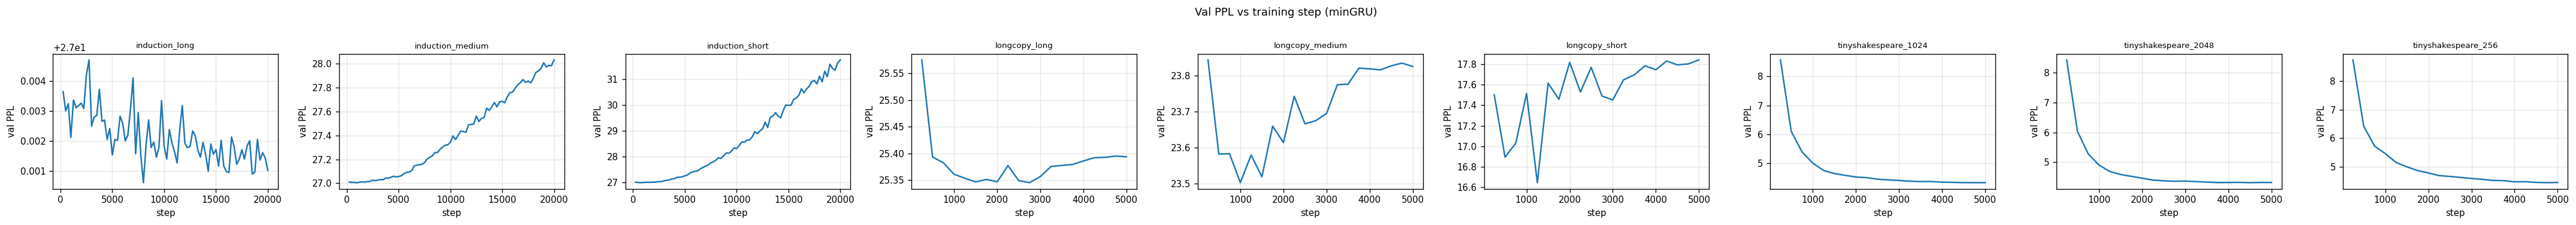

Saved: plot_learning_curves.png


In [17]:
# ── Plot 1: learning curves ──────────────────────────────────────────────
def load_metrics(run_dir):
    path = Path(run_dir) / 'metrics.csv'
    if not path.exists():
        return []
    with open(path) as f:
        return list(csv.DictReader(f))

run_dirs = sorted(
    [d for d in RUNS_ROOT.iterdir() if d.is_dir() and not d.name.startswith('smoke')],
    key=lambda d: d.name
)

if not run_dirs:
    print('No completed runs found in runs/ yet. Run Section 4 first.')
else:
    fig, axes = plt.subplots(
        1, max(1, len(run_dirs)), figsize=(4 * max(1, len(run_dirs)), 3),
        squeeze=False
    )
    for ax, run_dir in zip(axes[0], run_dirs):
        rows = load_metrics(run_dir)
        if not rows:
            ax.set_title(f'{run_dir.name[:30]}\n(no metrics)')
            continue
        steps = [int(r['step']) for r in rows]
        val_ppl = []
        for r in rows:
            try:
                val_ppl.append(float(r['val_ppl']))
            except (ValueError, KeyError):
                val_ppl.append(float('nan'))
        ax.plot(steps, val_ppl, linewidth=1.5)
        ax.set_xlabel('step')
        ax.set_ylabel('val PPL')
        short_name = run_dir.name.replace('mingru_', '').split('__')[0]
        ax.set_title(short_name, fontsize=8)
        ax.grid(True, alpha=0.3)
    plt.suptitle('Val PPL vs training step (minGRU)', y=1.02)
    plt.tight_layout()
    plt.savefig(REPO_ROOT / 'plot_learning_curves.png', bbox_inches='tight')
    plt.show()
    print('Saved: plot_learning_curves.png')


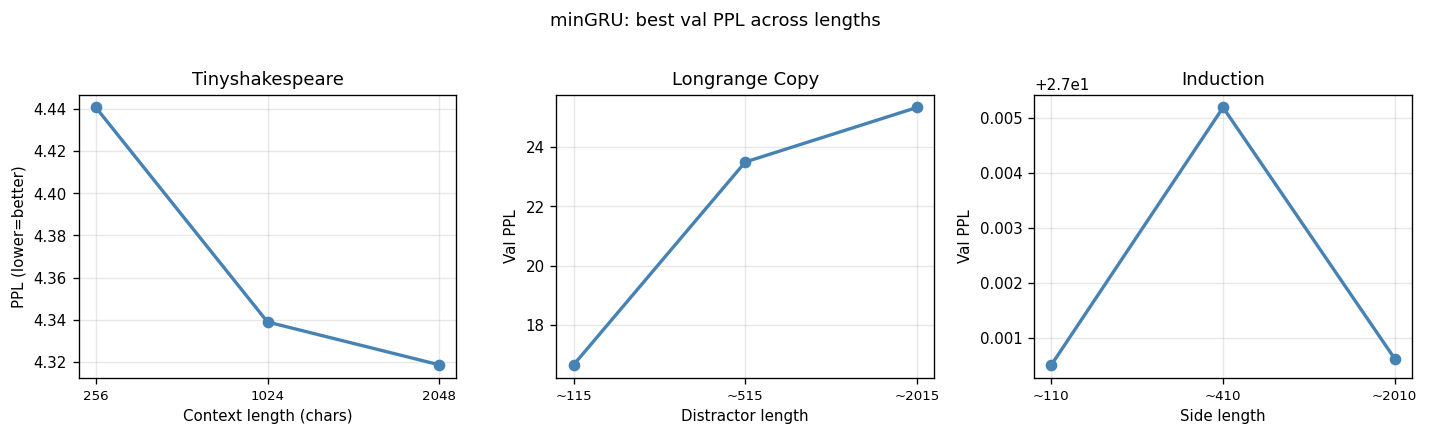

Saved: plot_ppl_by_length.png


In [18]:
# ── Plot 2: best PPL across lengths per task ────────────────────────────
per_run_rows = read_csv(summary_path)

if not per_run_rows:
    print('summary.csv is empty. Run Section 5 first.')
else:
    TASKS = [
        ('tinyshakespeare', [256, 1024, 2048],  'Context length (chars)', 'PPL (lower=better)'),
        ('longrange_copy',  ['short', 'medium', 'long'], 'Distractor length', 'Val PPL'),
        ('induction',       ['short', 'medium', 'long'], 'Side length',       'Val PPL'),
    ]
    LENGTH_LABEL = {
        'tinyshakespeare': {256: '256', 1024: '1024', 2048: '2048'},
        'longrange_copy':  {'short': '~115', 'medium': '~515', 'long': '~2015'},
        'induction':       {'short': '~110', 'medium': '~410', 'long': '~2010'},
    }
    fig, axes = plt.subplots(1, 3, figsize=(12, 3.5))
    for ax, (task, lengths, xlabel, ylabel) in zip(axes, TASKS):
        task_rows = [r for r in per_run_rows if r['task'] == task]
        xs, ys = [], []
        for i, length in enumerate(lengths):
            # Match by block_size (TS) or length_tier (synth)
            if task == 'tinyshakespeare':
                match = [r for r in task_rows if r.get('block_size') == str(length)]
            else:
                match = [r for r in task_rows if r.get('length_tier') == length]
            if match:
                try:
                    best_ppl = min(float(r['best_val_ppl']) for r in match
                                   if r['best_val_ppl'] and r['best_val_ppl'] != 'nan')
                    xs.append(i)
                    ys.append(best_ppl)
                except ValueError:
                    pass
        if xs:
            ax.plot(xs, ys, 'o-', color='steelblue', linewidth=2, markersize=6)
        ax.set_xticks(range(len(lengths)))
        ax.set_xticklabels([LENGTH_LABEL[task][l] for l in lengths], fontsize=8)
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_title(task.replace('_', ' ').title())
        ax.grid(True, alpha=0.3)
        if not xs:
            ax.text(0.5, 0.5, 'no data yet', ha='center', va='center',
                    transform=ax.transAxes, color='grey')
    plt.suptitle('minGRU: best val PPL across lengths', y=1.02)
    plt.tight_layout()
    plt.savefig(REPO_ROOT / 'plot_ppl_by_length.png', bbox_inches='tight')
    plt.show()
    print('Saved: plot_ppl_by_length.png')


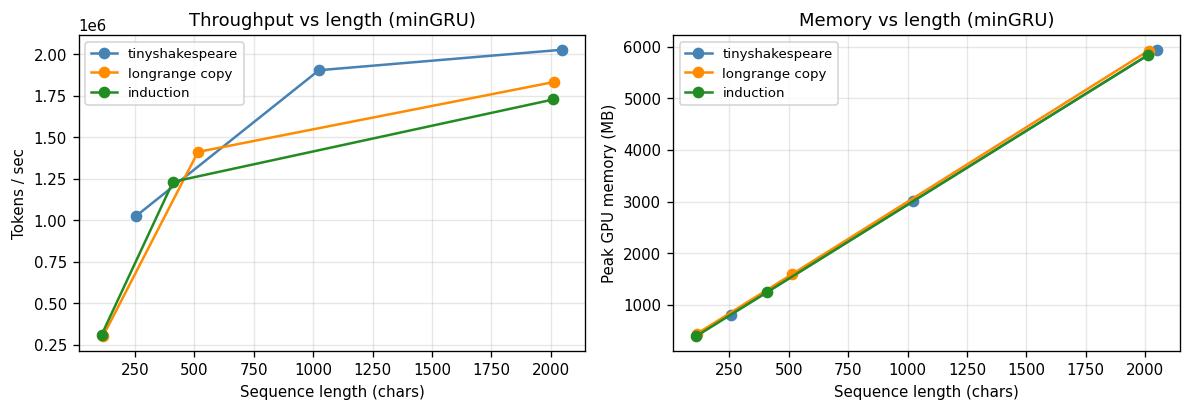

Saved: plot_throughput_memory.png


In [19]:
# ── Plot 3: throughput and memory vs length ──────────────────────────────
if not per_run_rows:
    print('summary.csv is empty. Run Section 5 first.')
else:
    LENGTH_ORDER = {
        'tinyshakespeare': {'256': 0,    '1024': 1,  '2048': 2},
        'longrange_copy':  {'short': 0,  'medium': 1, 'long': 2},
        'induction':       {'short': 0,  'medium': 1, 'long': 2},
    }
    LENGTH_CHARS = {
        'tinyshakespeare': {0: 256,    1: 1024,  2: 2048},
        'longrange_copy':  {0: 115,    1: 515,   2: 2015},
        'induction':       {0: 110,    1: 410,   2: 2010},
    }
    TASK_COLORS = {
        'tinyshakespeare': 'steelblue',
        'longrange_copy':  'darkorange',
        'induction':       'forestgreen',
    }

    fig, (ax_tps, ax_mem) = plt.subplots(1, 2, figsize=(10, 3.5))

    for task in ('tinyshakespeare', 'longrange_copy', 'induction'):
        task_rows = [r for r in per_run_rows if r['task'] == task]
        xs_tps, ys_tps = [], []
        xs_mem, ys_mem = [], []
        order_map = LENGTH_ORDER[task]
        chars_map = LENGTH_CHARS[task]
        for r in task_rows:
            key = r.get('block_size') if task == 'tinyshakespeare' else r.get('length_tier')
            if key not in order_map:
                continue
            idx = order_map[key]
            chars = chars_map[idx]
            try:
                tps = float(r['final_tokens_per_s'])
                if math.isfinite(tps) and tps > 0:
                    xs_tps.append(chars); ys_tps.append(tps)
            except (ValueError, KeyError):
                pass
            try:
                mem = float(r['final_peak_mem_mb'])
                if math.isfinite(mem) and mem > 0:
                    xs_mem.append(chars); ys_mem.append(mem)
            except (ValueError, KeyError):
                pass
        color = TASK_COLORS[task]
        label = task.replace('_', ' ')
        if xs_tps:
            paired = sorted(zip(xs_tps, ys_tps))
            ax_tps.plot(*zip(*paired), 'o-', color=color, label=label, linewidth=1.5)
        if xs_mem:
            paired = sorted(zip(xs_mem, ys_mem))
            ax_mem.plot(*zip(*paired), 'o-', color=color, label=label, linewidth=1.5)

    ax_tps.set_xlabel('Sequence length (chars)')
    ax_tps.set_ylabel('Tokens / sec')
    ax_tps.set_title('Throughput vs length (minGRU)')
    ax_tps.legend(fontsize=8)
    ax_tps.grid(True, alpha=0.3)

    ax_mem.set_xlabel('Sequence length (chars)')
    ax_mem.set_ylabel('Peak GPU memory (MB)')
    ax_mem.set_title('Memory vs length (minGRU)')
    ax_mem.legend(fontsize=8)
    ax_mem.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(REPO_ROOT / 'plot_throughput_memory.png', bbox_inches='tight')
    plt.show()
    print('Saved: plot_throughput_memory.png')


## Done

After completing all sections, share three files with the team:
- `summary.csv` — per-run results for Vibhansh's cross-paradigm plots
- `summary_per_cell.csv` — Table 1 values (best val PPL ± std)
- The smoke-test summary from `runs/smoke/smoke_summary.txt` — for the Day 3-4 gate


In [21]:
# Compare loss at recall positions vs distractor positions over the val set
import torch
from src.models.mingru import MinGRULM, MinGRUConfig
from src.training.checkpointing import load_checkpoint
from src.data.longrange_copy import LongRangeCopyDataset
from src.eval.metrics import _cross_entropy_per_token
from configs.model_mingru import default_mingru_config
import glob
from pathlib import Path

ckpt_dirs = sorted(glob.glob("runs/mingru_longcopy_short_diagnostic__*"))
ckpt_path = Path(ckpt_dirs[-1]) / "checkpoints" / "best.pt"

cfg_dict = default_mingru_config(vocab_size=55)
model = MinGRULM(MinGRUConfig(**cfg_dict)).cuda()
load_checkpoint(ckpt_path, model, map_location="cuda")
model.eval()

ds = LongRangeCopyDataset("data/longrange_copy", split="val", length="short")

recall_losses, distractor_losses = [], []
with torch.no_grad():
    for x, y, mask in ds.iter_batches(batch_size=64, device="cuda"):
        logits = model(x)
        loss = _cross_entropy_per_token(logits, y)   # [B, T]
        recall_losses.append(loss[mask].mean().item())
        distractor_losses.append(loss[~mask].mean().item())

print(f"Distractor loss : {sum(distractor_losses)/len(distractor_losses):.4f}  "
      f"(PPL {torch.tensor(sum(distractor_losses)/len(distractor_losses)).exp():.2f})")
print(f"Recall loss     : {sum(recall_losses)/len(recall_losses):.4f}  "
      f"(PPL {torch.tensor(sum(recall_losses)/len(recall_losses)).exp():.2f})")

IndexError: list index out of range